In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path
import os
import pandas as pd
SCRIPTS = Path().resolve() / ".."
if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as units
import astropy.constants as constants
import utils

%matplotlib inline

In [4]:
from astropy.io import ascii

tab = ascii.read('apjae27c5t6_mrt.txt', format='cds')

In [9]:
t = tab[tab['Galaxy'] == 'Fornax']

In [2]:
from astropy.io import ascii
from astropy.utils.data import download_file
import urllib.request

urllib.request.urlretrieve("https://cdsarc.cds.unistra.fr/ftp/J/AJ/137/3100/table3.dat", "table3.dat")
urllib.request.urlretrieve("https://cdsarc.cds.unistra.fr/ftp/J/AJ/137/3100/ReadMe", "ReadMe")

t = ascii.read("table3.dat", readme="ReadMe", format='cds')

t['FeH'] =  1.76 * t['SigFe'] - 2.11
from astropy.coordinates import SkyCoord
import astropy.units as u

sign = np.where(t['DE-'] == '-', -1, 1)

coords = SkyCoord(
    ra=15 * (t['RAh'].value + t['RAm'].value/60 + t['RAs'].value/3600),
    dec=sign * (t['DEd'].value + t['DEm'].value/60 + t['DEs'].value/3600),
    unit=u.deg
)

t['RA_DEG']  = coords.ra.deg
t['DEC_DEG'] = coords.dec.deg

# Fornax center
ra_center  = 15 * (2 + 39/60 + 59.3/3600) 
dec_center = -(34 + 26/60 + 57/3600)

t['radius']= np.sqrt((t['RA_DEG'] - ra_center)**2 * np.cos(np.radians(dec_center))**2 + (t['DEC_DEG'] - dec_center)**2)


In [3]:
np.random.seed(42)

tdown = t#[np.random.choice(len(t), size=200, replace=False)]
v_mu = np.mean(tdown['HV'])
v_std = np.std(tdown['HV'])
mask = np.abs(tdown['HV'] - v_mu) < 3 * v_std
tdown = tdown[mask]

In [4]:
R_proj = tdown['radius']
vlos = tdown['HV']-np.mean(t['HV'])
vlos_err = tdown['e_HV']

vdisp_binned_res = utils.calc_vdisp_los_binned(
    R_proj, vlos, vlos_err,
    ntracer_per_bin=50)

100%|██████████| 2000/2000 [00:01<00:00, 1127.70it/s]


Autocorrelation times: [23.3106143  20.98896763]
Mean tau: 22.1 steps (total chain: 2000 steps)
Discarded 69 steps, thinned by 10
Final sample size: 1544


100%|██████████| 2000/2000 [00:01<00:00, 1214.01it/s]


Autocorrelation times: [26.58680399 19.47554047]
Mean tau: 23.0 steps (total chain: 2000 steps)
Discarded 79 steps, thinned by 9
Final sample size: 1704


100%|██████████| 2000/2000 [00:01<00:00, 1244.48it/s]


...

Autocorrelation times: [17.91554895 19.37102745]
Mean tau: 18.6 steps (total chain: 2000 steps)
Discarded 58 steps, thinned by 8
Final sample size: 1936


100%|██████████| 2000/2000 [00:01<00:00, 1243.75it/s]


Autocorrelation times: [19.20320413 11.92670425]
Mean tau: 15.6 steps (total chain: 2000 steps)
Discarded 57 steps, thinned by 5
Final sample size: 3104


100%|██████████| 2000/2000 [00:01<00:00, 1255.05it/s]

Autocorrelation times: [21.11423717 25.93333711]
Mean tau: 23.5 steps (total chain: 2000 steps)
Discarded 77 steps, thinned by 10
Final sample size: 1536


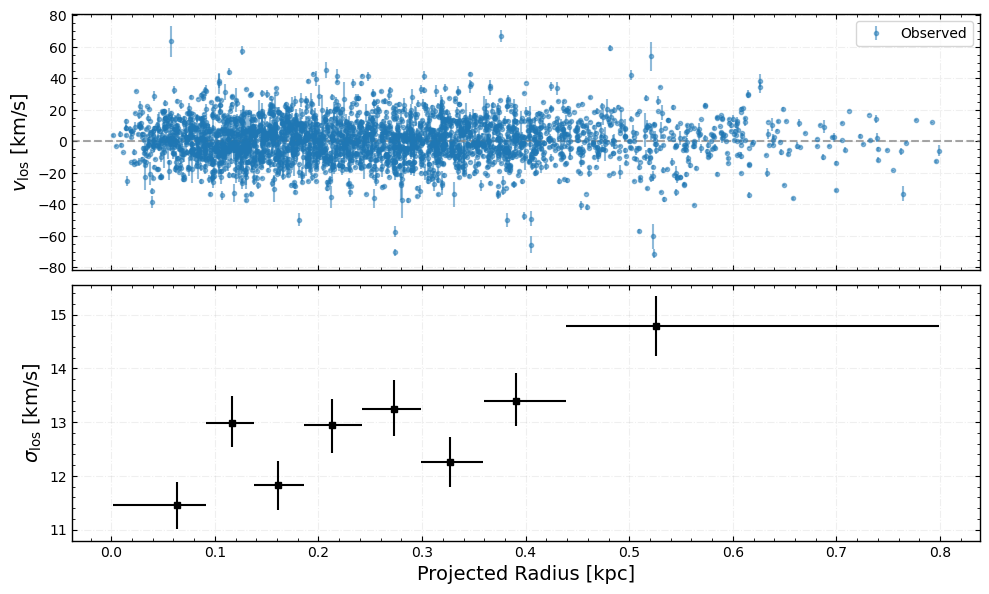

In [5]:
fig, axes = plt.subplots(2, figsize=(10, 6), sharex=True, tight_layout=True)

axes[0].errorbar(R_proj, vlos, yerr=vlos_err, fmt='o', markersize=3, alpha=0.5, label='Observed')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[0].set_ylabel(r'$v_\mathrm{los}$ [km/s]', fontsize=14)
# axes[0].set_ylim(-30, 30)

# plot the binned velocity dispersion
R_mid = vdisp_binned_res['R_mid']
R_em = vdisp_binned_res['R_em']
R_ep = vdisp_binned_res['R_ep']
sigma = vdisp_binned_res['sigma']
sigma_em = vdisp_binned_res['sigma_em']
sigma_ep = vdisp_binned_res['sigma_ep']
axes[1].errorbar(
    R_mid, sigma,
    yerr=[sigma_em, sigma_ep],
    xerr=[R_em, R_ep],
    fmt='s', color='black',
    markersize=4, label='Binned Dispersion')
axes[1].set_ylabel(r'$\sigma_\mathrm{los}$ [km/s]', fontsize=14)
axes[1].set_xlabel('Projected Radius [kpc]', fontsize=14)

axes[0].legend()
plt.show()

In [6]:
import scipy.special as sc
from scipy.interpolate import interp1d
from scipy.integrate import quad

class ConstantAnisotropyJeans:
    """
    A class to model the radial velocity dispersion profile of a spherical and
    isotropic systems using the Jeans equation. Code adapted from Kohei Hayashi.

    Attributes:
        param (list): List of parameters for the model.
        log_rho_s (float): Logarithm (base 10) of rho_s.
        rho_s (float): Scale density [10^7 M_solar/kpc^3].
        log_r_s (float): Logarithm (base 10) of r_s.
        r_s (float): Scale radius [kpc].
        gam (float): Gamma parameter.
        rh (float): Half-light radius [kpc].
        vsys (float): Systemic velocity [km/s].
        r_vec (np.ndarray): Array of radii [kpc] for calculations.
    """
    def __init__(self, theta, beta0, min_radius=1e-3, max_radius=5, n_radius=200):
        """
        Args:
            theta (list): List of parameters for the model.
            beta0 (float): The velocity anisotropy parameter.
            min_radius (float, optional): Minimum radius [kpc]. Defaults to 1e-3.
            max_radius (float, optional): Maximum radius [kpc]. Defaults to 5.
            n_radius (int, optional): Number of radius points. Defaults to 200.
        """
        self.param = theta
        self.log_rho_s = self.param[0]  # log10(rho_s)
        self.rho_s = 10.0 ** self.param[0]  # rho_s [10^7 M_solar/kpc^3]
        self.log_r_s = self.param[1]  # log10(r_s)
        self.r_s = 10.0 ** self.param[1]  # r_s [kpc]
        self.gam = self.param[2]  # gamma
        self.rh = self.param[3]  # r_half [kpc]
        self.vsys = self.param[4]  # Vsys [km/s]
        self.beta0 = beta0  # constant anisotropy parameter

        self.r_vec = np.logspace(np.log10(min_radius), np.log10(max_radius), n_radius)

    def rho(self, r):
        """
        Compute the dark matter density profile for dwarf spheroidal galaxies (dSphs).
        Assume generalized NFW profile with alpha=1 and beta=3.

        Args:
            r (float): Radius [kpc].

        Returns:
            float: Dark matter density at radius r in units of 10^7 M_solar/kpc^3.
        """
        c1 = self.rho_s * (r / self.r_s)**(-self.gam)
        c2 = (1 + (r / self.r_s))**(-(3 - self.gam))
        return c1 * c2

    def M(self, r):
        """
        Compute the dark matter mass profile for dSphs.
        This can be obtained by integrating the density profile, but for the generalized NFW profile,
        there exists an analytical expression.

        Args:
            r (float): Radius [kpc].

        Returns:
            float: Dark matter mass at radius r in units of 10^7 M_solar.
        """
        r_n = r / self.r_s
        c1 = (4 * np.pi * self.rho_s * self.r_s**3) / (3.0 - self.gam)
        c2 = r_n ** (3.0 - self.gam)
        return c1 * c2 * sc.hyp2f1(
            3.0 - self.gam, 3.0 - self.gam, 1.0 + (3.0 - self.gam), -r_n)

    def nu(self, r):
        """
        Compute the 3D stellar density profile assuming a Plummer profile.
        Ignoring mass-to-light ratio, since it cancels out in the Jeans equation.

        Args:
            r (float): Radius [kpc].

        Returns:
            float: Stellar density at radius r.
        """
        return 3.0 / (4.0 * np.pi * self.rh**3) * (1 + (r / self.rh)**2)**(-2.5)

    def I(self, R):
        """
        Compute the projected stellar density profile assuming a Plummer profile.

        Args:
            R (float): Projected radius [kpc].

        Returns:
            float: Projected stellar density at radius R.
        """
        return 1.0 / (np.pi * self.rh**2) * (1 + (R / self.rh)**2)**(-2)

    def beta(self, r):
        """
        Velocity anisotropy parameter (isotropic case).

        Args:
            r (float): Radius [kpc].

        Returns:
            float: Velocity anisotropy parameter at radius r.
        """
        return self.beta0

    def gbeta(self, r):
        """
        Compute the function g(r) related to the velocity anisotropy.

        Args:
            r (float): Radius [kpc].

        Returns:
            float: g(r) value at radius r.
        """
        return r**(2 * self.beta0)

    # =========================================================================
    # TODO: Implement the two methods below (_sigma2_r and _sigma2_los_R).
    #
    # These are "private" helper methods (prefixed with _) that compute the
    # velocity dispersion at a SINGLE radius. The public methods (sigma2 and
    # sigma2_los) handle vectorization by calling these helpers over a grid
    # of radii and building an interpolator for efficiency.
    #
    # This separation allows you to focus on the physics (the integrals) in
    # the private methods, while the public methods handle the numerical
    # details of interpolation.
    # =========================================================================

    def _sigma2_r(self, r):
        """
        Compute the radial velocity dispersion squared at a single radius r.

        TODO: Implement the Jeans equation solution for sigma_r^2(r):
            sigma_r^2(r) = (1 / (nu * g)) * integral_r^inf [ nu(s) * g(s) * G*M(s)/s^2 ] ds

        Hint: Define an integrand function and use scipy.integrate.quad.
        Use self.nu(), self.gbeta(), self.M(), and constants.G.value.
        Make sure to convert units appropriately to get the final result in [km^2/s^2].

        Args:
            r (float): Radius [kpc].

        Returns:
            float: Radial velocity dispersion squared at radius r in units of [km^2/s^2].
        """
        def integrand(s):
            return constants.G.value * self.M(s) / s**2 * self.nu(s) * self.gbeta(s)
        import scipy.integrate
        _first = (1 / (self.nu(r) * self.gbeta(r)))  # dimensionless (nu cancels)

        _second = quad(integrand, r, np.inf)[0] * units.m**3 * (1e7*units.M_sun) / (units.kg * units.s**2 * units.kpc)

        return (_first * _second).to(units.km**2 / units.s**2).value


    def _sigma2_los_R(self, R, sigma2_r_fn):
        """
        Compute the line-of-sight velocity dispersion squared at a single projected radius R.

        TODO: Implement the Abel integral projection:
            sigma_los^2(R) = (2 / I(R)) * integral_R^inf [ (1 - beta*R^2/r^2) * nu * sigma_r^2 * r / sqrt(r^2 - R^2) ] dr

        Hint: The integrand has three parts:
            1. anisotropy_term = 1 - beta * (R/r)^2
            2. kernel = r / sqrt(r^2 - R^2)
            3. density and dispersion = nu(r) * sigma2_r_fn(r)

        Args:
            R (float): Projected radius [kpc].
            sigma2_r_fn (callable): Interpolated function for sigma_r^2(r).

        Returns:
            float: Line-of-sight velocity dispersion squared at radius R in units of [km^2/s^2].
        """
        ### TODO: Your implementation here ###

        def integrand(s):
            _c1 = 1 - self.beta(s) * R**2/s**2
            _c2 = s / np.sqrt(s**2 - R**2)
            _c3 = self.nu(s) * sigma2_r_fn(s)
            return _c1 * _c2 * _c3
        
        _c0 = 2/self.I(R)

        integral, _ = quad(integrand, R, np.inf, epsabs=1, epsrel=1)

        return _c0 * integral
    


    # =========================================================================
    # Public methods below: these handle vectorization and interpolation.
    # You do NOT need to modify these.
    # =========================================================================

    def sigma2(self, r_vec):
        """
        Compute sigma_r^2 over an array of radii and return an interpolator.

        This method evaluates _sigma2_r at each radius in r_vec, then returns
        an interpolated function for fast evaluation at arbitrary radii.

        Args:
            r_vec (array-like): Array of radii [kpc].

        Returns:
            callable: Interpolated function for radial velocity dispersion squared.
        """
        return interp1d(
            r_vec,
            list(map(self._sigma2_r, r_vec)),
            bounds_error=False,
            fill_value=0.0,
            kind="linear",
        )

    def sigma2_los(self, min_radius=1e-3):
        """
        Compute the line-of-sight velocity dispersion profile.

        Args:
            min_radius (float, optional): Minimum radius [kpc]. Defaults to 1e-3.

        Returns:
            np.ndarray: Array of line-of-sight velocity dispersion values.
        """
        # Pre-compute sigma_r^2 on a fine grid and interpolate
        r_grid = np.logspace(np.log10(min_radius), np.log10(50), 500)
        sigma2_r_fn = self.sigma2(r_grid)

        # Compute sigma_los^2 at each projected radius
        sigma2_los = np.array([
            self._sigma2_los_R(R, sigma2_r_fn) for R in self.r_vec
        ])
        return sigma2_los

In [7]:
def log_likelihood_free_beta(theta, r_obs, v_obs, v_err_obs):
    """
    Compute the log likelihood for the Jeans model with free anisotropy parameter.

    TODO: Implement the Gaussian log-likelihood with free beta parameter.

    Hint: Make the last parameter in theta represent 2^beta and follow the likelihood
    implementation as the previous one.

    Args:
        theta (np.ndarray): Model parameters [log_rho_s, log_r_s, gam, rh, vsys, two_to_beta].
            Note: the last parameter is 2^beta, not beta directly.
        r_obs (np.ndarray): Observed projected radii [kpc].
        v_obs (np.ndarray): Observed line-of-sight velocities [km/s].
        v_err_obs (np.ndarray): Velocity measurement errors [km/s].

    Returns:
        float: Log likelihood value, or -inf if model is invalid.
    """
    theta_jeans = theta[:5]  # [log_rho_s, log_r_s, gam, rh, vsys]
    two_to_beta0 = theta[5]  # 2^beta0
    beta0 = np.log2(two_to_beta0)

    # beta0 is constrained to between -infinity and 1
    if beta0 >= 1.0:
        return -np.inf

    # Compute the dispersion sigma2_los on the model grid and interpolate to observed radii
    model = ConstantAnisotropyJeans(theta_jeans, beta0)
    sigma2_los_grid = model.sigma2_los()
    sigma2_los_fn = interp1d(
        model.r_vec, sigma2_los_grid,
        bounds_error=False, fill_value=0.0, kind="linear"
    )
    sigma2_los = sigma2_los_fn(r_obs)

    # Check for invalid dispersion values
    if np.any(sigma2_los <= 0):
        return -np.inf

    # Compute total variance and the log-likelihood
    # note how the variance is added in quadrature
    sigma2_tot = sigma2_los + v_err_obs**2
    lnlike = norm.logpdf(v_obs, loc=model.vsys, scale=np.sqrt(sigma2_tot))

    if np.any(~np.isfinite(lnlike)):
        return -np.inf

    return lnlike.sum()

In [8]:
# Constructing priors with free beta
from scipy.stats import uniform, norm
import multiprocess as mp
import pocomc as pc


class UniformPrior():
    def __init__(self, name, low, high):
        self.name = name
        self.low = low
        self.high = high
        self.dist = uniform(loc=low, scale=high - low)

    def logpdf(self, x):
        return self.dist.logpdf(x)

    def rvs(self, size=1):
        return self.dist.rvs(size=size)

r_half_kpc = 0.668

priors_free_beta = dict(
    log_rho_s=UniformPrior("log_rho_s", -3.0, 3.0),  # 10^7 M_sun/kpc^3
    log_r_s=UniformPrior("log_r_s", -3.0, 3.0),  # kpc
    gam=UniformPrior("gam", 0.0, 1.5),
    rh=UniformPrior("rh", r_half_kpc - 0.1, r_half_kpc + 0.1),
    vsys=UniformPrior("vsys", -1e3, 1e3),
    two_to_beta=UniformPrior("two_to_beta", 0.25, 2.0),  # 2^beta, corresponds to beta in [-2, 1]
)

# make sure order matches theta in model
prior_list_free_beta = [
    priors_free_beta[key].dist for key in
    ["log_rho_s", "log_r_s", "gam", "rh", "vsys", "two_to_beta"]
]

# create pocomc Prior object
pc_priors_free_beta = pc.Prior(prior_list_free_beta)

In [9]:
# Run sampler with free beta
n_cpus = 11
n_total = 2000

print(f"\nRunning sampler with free beta, {n_cpus} CPUs, n_total={n_total} samples...\n")

with mp.Pool(n_cpus) as pool:
    sampler_free_beta = pc.Sampler(
        prior=pc_priors_free_beta,
        likelihood=log_likelihood_free_beta,
        likelihood_kwargs=dict(
            r_obs=R_proj,
            v_obs=vlos,
            v_err_obs=vlos_err,
        ),
        pool=pool,
        vectorize=False,
    )
    sampler_free_beta.run(n_total=n_total, progress=True)
    samples_free_beta, logl_free_beta, logp_free_beta = sampler_free_beta.posterior(resample=True)


Running sampler with free beta, 11 CPUs, n_total=2000 samples...



Iter: 34it [18:14, 32.20s/it, beta=1, calls=55040, ESS=1874, logZ=-1.24e+4, logP=-1.24e+4, acc=0.238, steps=21, eff=0.742]  


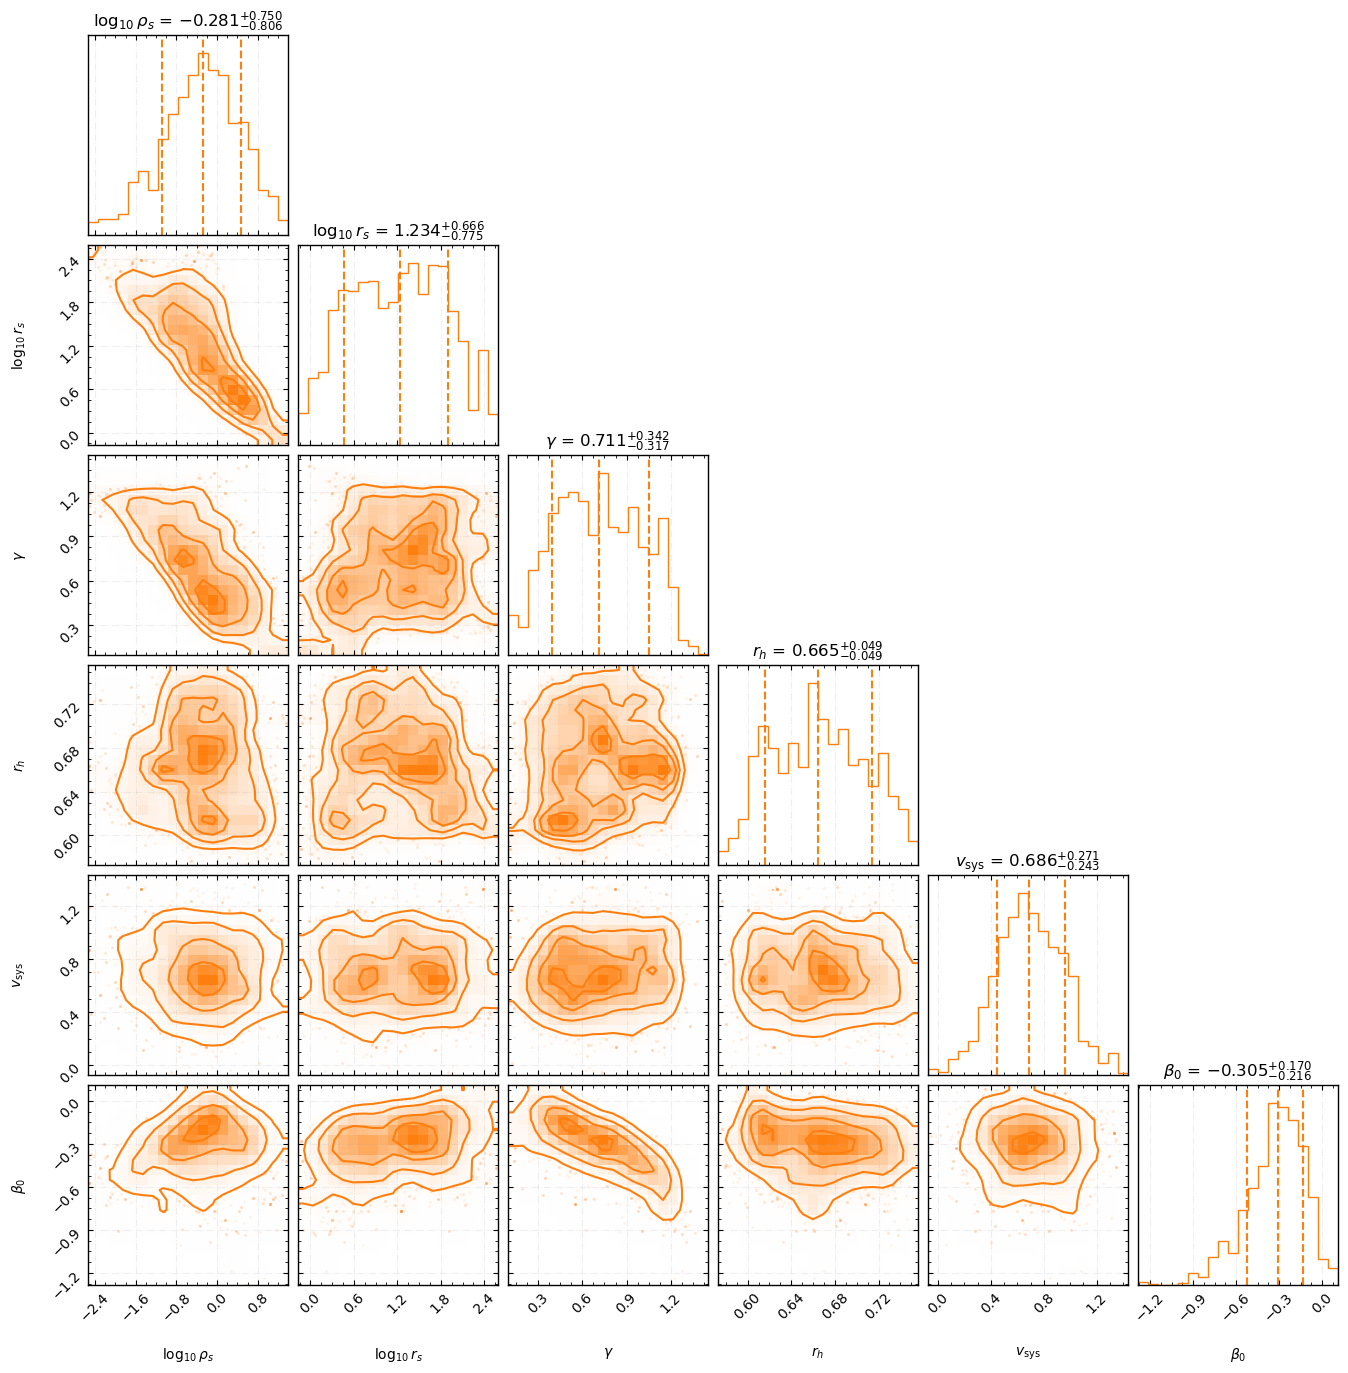

In [17]:
# Convert 2^beta samples to beta for plotting
import corner

# save samples
np.save("samples_free_beta.npy", samples_free_beta)

samples_free_beta_plot = samples_free_beta.copy()
samples_free_beta_plot[:, 5] = np.log2(samples_free_beta[:, 5])  # convert 2^beta to beta


# plot corner plots
fig = corner.corner(
    samples_free_beta_plot,
    labels=[r"$\log_{10}\rho_s$", r"$\log_{10}r_s$", r"$\gamma$", r"$r_h$", r"$v_{\rm sys}$", r"$\beta_0$"],
    quantiles=[0.16, 0.5, 0.84],
    truth_color='k',
    color='C1',
    show_titles=True,
    title_fmt=".3f",
    title_kwargs={"fontsize": 12},
    smooth=1
)

plt.savefig("corner_free_beta.png", dpi=300)

In [11]:
# Compute posterior profiles with free beta
r_plot = np.logspace(-2, 2, 50)
num_max_samples = 500
samples_choice_fb = np.random.choice(
    samples_free_beta.shape[0], size=num_max_samples, replace=False)

rho_dm_samples_fb = np.zeros((num_max_samples, len(r_plot)))
mass_dm_samples_fb = np.zeros((num_max_samples, len(r_plot)))
vdisp_samples_fb = np.zeros((num_max_samples, len(r_plot)))

for i, theta_sample in enumerate(samples_free_beta[samples_choice_fb]):
    theta_jeans = theta_sample[:5]
    beta0 = np.log2(theta_sample[5])  # convert 2^beta to beta
    model = ConstantAnisotropyJeans(
        theta_jeans, beta0=beta0, min_radius=0.01, max_radius=100, n_radius=50)
    rho_dm_samples_fb[i] = model.rho(r_plot)
    mass_dm_samples_fb[i] = model.M(r_plot)
    vdisp_samples_fb[i] = np.sqrt(model.sigma2_los())

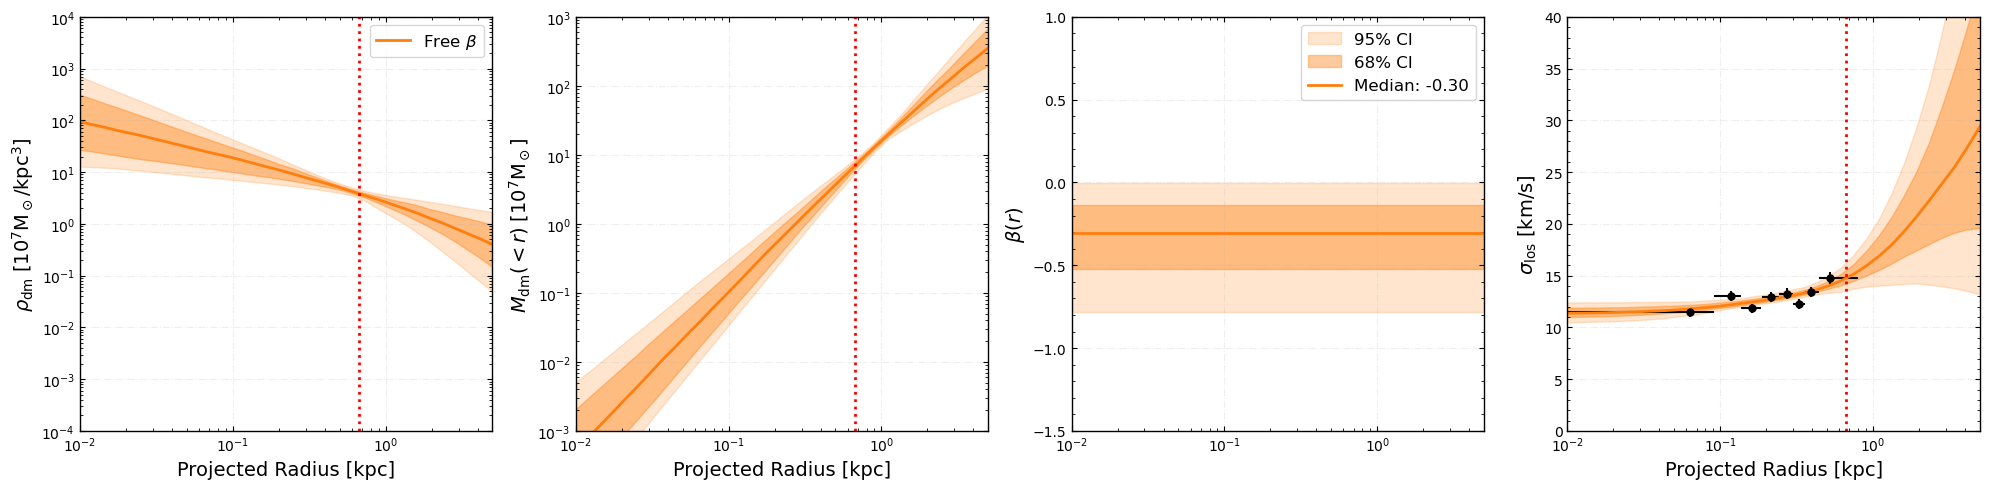

In [18]:
percentiles = [2, 16, 50, 84, 98]

fig, axes = plt.subplots(1, 4, figsize=(20, 5), tight_layout=True, sharex=True)

# ---- Dark Matter Density Profile ----
ax = axes[0]
rho_dm_q_fb = np.percentile(rho_dm_samples_fb, percentiles, axis=0)
ax.fill_between(r_plot, rho_dm_q_fb[0], rho_dm_q_fb[4], color='C1', alpha=0.2)
ax.fill_between(r_plot, rho_dm_q_fb[1], rho_dm_q_fb[3], color='C1', alpha=0.4)
ax.plot(r_plot, rho_dm_q_fb[2], color='C1', linestyle='-', lw=2, label=r'Free $\beta$')
ax.axvline(r_half_kpc, color='red', linestyle=':', lw=2)
ax.set_ylim(1e-4, 1e4)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Projected Radius [kpc]', fontsize=14)
ax.set_ylabel(r'$\rho_\mathrm{dm} \; [10^7 \mathrm{M_\odot/kpc^3}]$', fontsize=14)
ax.legend(fontsize=12)

# ---- Enclosed Mass Profile ----
ax = axes[1]
mass_dm_q_fb = np.percentile(mass_dm_samples_fb, percentiles, axis=0)
ax.fill_between(r_plot, mass_dm_q_fb[0], mass_dm_q_fb[4], color='C1', alpha=0.2)
ax.fill_between(r_plot, mass_dm_q_fb[1], mass_dm_q_fb[3], color='C1', alpha=0.4)
ax.plot(r_plot, mass_dm_q_fb[2], color='C1', linestyle='-', lw=2, label=r'Free $\beta$')
ax.axvline(r_half_kpc, color='red', linestyle=':', lw=2)
ax.set_ylim(1e-3, 1e3)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Projected Radius [kpc]', fontsize=14)
ax.set_ylabel(r'$M_\mathrm{dm}(<r) \; [10^7 \mathrm{M_\odot}]$', fontsize=14)

# ---- Beta Posterior ----
ax = axes[2]
beta_samples = np.log2(samples_free_beta[:, 5])
beta_median = np.median(beta_samples)
beta_16, beta_84 = np.percentile(beta_samples, [16, 84])
beta_2, beta_98 = np.percentile(beta_samples, [2, 98])

ax.axhspan(beta_2, beta_98, color='C1', alpha=0.2, label='95% CI')
ax.axhspan(beta_16, beta_84, color='C1', alpha=0.4, label='68% CI')
ax.axhline(beta_median, color='C1', linestyle='-', lw=2, label=f'Median: {beta_median:.2f}')
ax.set_ylim(-1.5, 1.0)
ax.set_ylabel(r'$\beta(r)$', fontsize=14)
ax.legend(fontsize=12, loc='upper right')

# ---- Velocity Dispersion Profile ----
ax = axes[3]
ax.errorbar(
    R_mid, sigma,
    yerr=[sigma_em, sigma_ep],
    xerr=[R_em, R_ep],
    fmt='o', color='black',
    markersize=5, label='Binned Data'
)
vdisp_q_fb = np.percentile(vdisp_samples_fb, percentiles, axis=0)
ax.fill_between(r_plot, vdisp_q_fb[0], vdisp_q_fb[4], color='C1', alpha=0.2)
ax.fill_between(r_plot, vdisp_q_fb[1], vdisp_q_fb[3], color='C1', alpha=0.4)
ax.plot(r_plot, vdisp_q_fb[2], color='C1', linestyle='-', lw=2, label=r'Free $\beta$')
ax.axvline(r_half_kpc, color='red', linestyle=':', lw=2)
ax.set_xscale('log')
ax.set_xlabel('Projected Radius [kpc]', fontsize=14)
ax.set_ylabel(r'$\sigma_\mathrm{los}$ [km/s]', fontsize=14)
ax.set_xlim(0.01, 5)
ax.set_ylim(0, 40)
plt.savefig("dispersion_profile_free_beta.png", dpi=300)

In [14]:
idx = np.argmin(np.abs(r_plot - r_half_kpc))
mass_dm_q_fb[2][idx]

np.float64(5.944834093838163)